Langgraph -节点与可控制性
******
*   第一个Langgraph
*   基本控制：串行控制
*   基本控制：分支控制
*   基本控制：条件与循环
*   精细控制：图的运行时配置
*   精细控制：map-reduce


In [1]:
! pip install -U langgraph

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/65/4c/09a4a0c42f5d2fc38d6c4d67884788eff7fd2cfdf367fdf7033de908b4c0/langgraph_checkpoint-4.0.1-py3-none-any.whl (50 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/dc/41/ec966424ad3f2ed3996d24079d3342c8cd6c0bd0653c12b2a917a685ec6c/langgraph_prebuilt-1.0.8-py3-none-any.whl (35 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/7a/0c/9803aa883d18c7ef197213cd2cbf73ba76472a11fe100fb7dab2884edf48/ormsgpack-1.12.2-cp312-cp312-win_amd64.whl (117 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/34/70/2e0855361f76198a3965273048c8e50a9695d88cd75811a5b46444895845/orjson-3.11.7-cp312-cp312-win_amd64.whl (125 kB)
  Attempting uninstall: orjson
    Found existing installation: orjson 3.10.15
    Uninstalling orjson-3.10.15:
      Successfully uninstalled orjson-3.10.15


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.10.0 requires aiofiles<24.0,>=22.0, but you have aiofiles 25.1.0 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# 定义state
# TypeDict:属于python的标准库typing模块的一部分，仅提供静态类型检查，运行时不执行炎症
# Pydantic：第三方库，需要单独安装，提供运行时数据验证和序列化功能
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict

class State(TypedDict):
    messages:list[AnyMessage]
    extra_field:int


In [15]:
# 定义节点
from langchain_core.messages import AIMessage

def node(state:State):
    messages= state["messages"]
    mew_messages = AIMessage("你好！我是节点1")
    return{
        "messages":messages + [mew_messages],
        "extra_field":1
    }

In [16]:
# 创建图
# 包含一个节点并使用state通信

from langgraph.graph import StateGraph

graph = StateGraph(State)
graph.add_node(node)
graph.set_entry_point("node")
graph_builder = graph.compile()

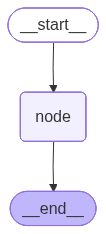

In [17]:
# 查看节点与图结构
# 主要使用Mermaid，基于文本的图标和可视化工具
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [18]:
from langchain_core.messages import HumanMessage
result = graph_builder.invoke({
    "messages":[HumanMessage("你好，我是jan")]
})
result

{'messages': [HumanMessage(content='你好，我是jan', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好！我是节点1', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 1}

In [19]:
# 使用pretty_print来进行格式化
from langchain_core.messages import HumanMessage
result = graph_builder.invoke({
    "messages":[HumanMessage("你好，我是jan")]
})

for message in result["messages"]:
    message.pretty_print()


================================ Human Message =================================

你好，我是jan
================================== Ai Message ==================================

你好！我是节点1


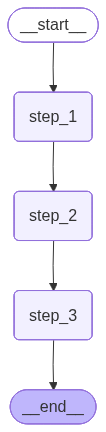

In [ ]:
# 串行控制
from typing_extensions import TypedDict
from IPython.display import Image,display
from langgraph.graph import START,END,StateGraph

class State(TypedDict):
    value_1:str
    value_2:str

def step_1(state:State):
    return{
        "value_1":"a"
    }

def step_2(state:State):
    current_value_1 = state["value_1"]
    return{
        "value2":f"{current_value_1} +b"
    }

def step_3(state:State):
    return {"value_2":10}

graph_builder = StateGraph(State)
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

graph_builder.add_edge(START,"step_1")
graph_builder.add_edge("step_1","step_2")
graph_builder.add_edge("step_2","step_3")
graph_builder.add_edge("step_3",END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [2]:
graph.invoke({"value_1":"c"})

{'value_1': 'a', 'value_2': 10}

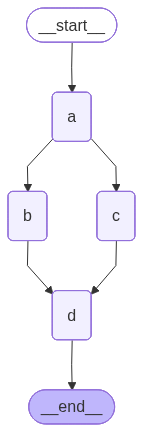

In [13]:
# 分支控制

from typing_extensions import TypedDict
from IPython.display import Image,display
from langgraph.graph import START,END,StateGraph
import operator
from typing import Any,Annotated

# 允许为类型提供欸外的元数据，不影响类型检查，对类型本身的理解
class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"添加A到{state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"添加B到{state['aggregate']}")
    return {"aggregate":["B"]}

def c(state:State):
    print(f"添加C到{state['aggregate']}")
    return {"aggregate":["C"]}

def d(state:State):
    print(f"添加D到{state['aggregate']}")
    return {"aggregate":["D"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

builder.add_edge(START,"a")
builder.add_edge("a","b")
builder.add_edge("a","c")
builder.add_edge("b","d")
builder.add_edge("c","d")
builder.add_edge("d",END)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [8]:
graph.invoke({"aggregate":[]},{"configurable":{"thread_id":"foo"}})

添加A到[]
添加B到['A']
添加C到['A']
添加D到['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

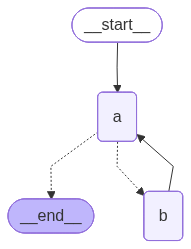

In [10]:
# 条件分支和循环
import operator
from typing import Annotated,Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

class State[TypedDict]:
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"Node Bsees {state['aggregate']}")
    return {"aggregate":["A"]}


def b(state:State):
    print(f"Node B sees {state['aggregate']}")
    return {"aggregate":["B"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)

def route(state:State) -> Literal["b",END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

builder.add_edge(START,"a")
builder.add_conditional_edges("a",route)
builder.add_edge("b","a")
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke({"aggregate":[]})

Node Bsees []
Node B sees ['A']
Node Bsees ['A', 'B']
Node B sees ['A', 'B', 'A']
Node Bsees ['A', 'B', 'A', 'B']
Node B sees ['A', 'B', 'A', 'B', 'A']
Node Bsees ['A', 'B', 'A', 'B', 'A', 'B']


{'aggregate': ['A', 'B', 'A', 'B', 'A', 'B', 'A']}

In [ ]:
# 图的运行时配置

import operator
from typing import Annotated,Sequence
from typing_extensions import TypedDict
from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
import os 
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import END,StateGraph,START
model = ChatDeepSeek(
    model="",
    temperature=0,
    api_key="",
    base_url=""
)

model2 = ChatOpenAI(
    model="",
    temperature=0,
    api_key="",
    base_url=""
)

models = {
    "deepseek":model,
    "openai":model2
}

class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],operator.add]

def _call_model(state:AgentState,config:RunnableConfig):
    model_name= config["configurable"].get("mode","deepseek")
    model = models[model_name]
    response = model.invoke(state["messages"])
    return {"messages":[response]}

builder = StateGraph(AgentState)

builder.add_node("model",_call_model)
builder.add_edge(START,"model")
builder.add_edge("model",END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
import operator
from typing import Annotated,Sequence
from langgraph.types import Send
from typing_extensions import TypedDict
from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field
import os 
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import END,StateGraph,START

subjects_prompt = """生成一个都好分割的列表，包含2到5个与以下主题相关的例子：{topic}。"""
joke_prompt = """生成一个关于{subject}的笑话"""
best_joke_prompt="""以下是一些关于{topic}的笑话。选出最好的一个！返回最佳笑话的ID{jokes}"""

class Subjects(BaseModel):
    subjects: list[str]

class Joke(BaseModel):
    joke:str

class BestJoke(BaseModel):
    id:int = Field(description="最佳笑话的索引，从0开始")

model = ChatDeepSeek(
    model="",
    temperature=0,
    api_key="",
    base_url=""
)

class OverallState(TypedDict):
    topic:str
    Subjects:list
    jokes:Annotated[list,operator.add]
    best_selected_joke:str

class JokeState(TypedDict):
    subjects:str

def generate_topics(state:OverallState):
    prompt=subjects_prompt.format(topic=state["topic"])
    response = model.with_structured_output(Subjects).invoke(prompt)
    return {"subjects":response.subjects}

def generate_joke(state:JokeState):
    prompt=joke_prompt.format(Subjects=state["subject"])
    response = model.with_structured_output(Joke).invoke(prompt)
    return {"jokes":response.joke}

def continue_to_jokes(state: OverallState):
    return [Send("generate_joke",{"subject":s}) for s in state["subjects"]]

def best_joke(state:OverallState):
    jokes="\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"],jokes=jokes)
    response = model.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke":state["jokes"][response.id]}


graph = StateGraph(OverallState)
graph.add_node("generate_topics",generate_topics)
graph.add_node("generate_joke",generate_joke)
graph.add_node("best_joke",best_joke)
graph.add_edge(START,"generate_topics")
graph.add_conditional_edges("generate_topics",continue_to_jokes,["generate_joke"])
graph.add_edge("generate_joke","best_joke")
graph.add_edge("best_joke",END)
app = graph.compile()

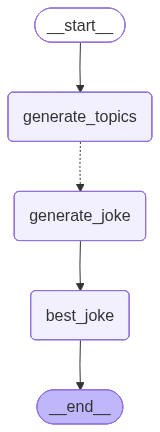

In [16]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [18]:
for s in app.stream({"topic":"动物"}):
    print(s)

BadRequestError: Error code: 400 - {'error': {'message': 'Model Not Exist', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}